# Customer (CIF) Data Analysis

This notebook walks through the customer generator, generates a population of synthetic customers, and analyzes the output distributions to verify the data looks realistic before handing it off for UAT.

**What we cover:**
1. Generate a customer population
2. Inspect a sample record
3. Age distribution
4. Employment status breakdown
5. Income distribution by employment type
6. Marital status breakdown
7. Geographic spread (state distribution)
8. Customer tenure (years with the bank)

## Setup

We add the project root to the Python path so the notebook can import from `src/` without needing a full package install.

In [1]:
import sys
from pathlib import Path

# Add project root to path so `src` imports work from within notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns
from datetime import date

from src.generators.customer import generate_customers
from src.models.customer import Customer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Setup complete.')

Setup complete.


## 1. Generate Customers

We use seed `42` throughout this notebook so every run produces the same dataset — important for reproducible analysis and consistent UAT data across teams.

In [2]:
SEED = 42
COUNT = 250

customers: list[Customer] = generate_customers(count=COUNT, seed=SEED)
print(f'Generated {len(customers):,} customers with seed={SEED}')

Generated 250 customers with seed=42


## 2. Inspect a Sample Record

Before analyzing distributions, look at a single raw record to confirm the field shapes and values look right.

In [3]:
sample = customers[0]
print(f'Customer ID  : {sample.customer_id}')
print(f'Name         : {sample.first_name} {sample.last_name}')
print(f'DOB          : {sample.date_of_birth}')
print(f'SSN          : {sample.ssn}')
print(f'Email        : {sample.email}')
print(f'Phone        : {sample.phone}')
print(f'Address      : {sample.address.street}')
print(f'               {sample.address.city}, {sample.address.state} {sample.address.zip_code}')
print(f'Marital      : {sample.marital_status}')
print(f'Employment   : {sample.employment_status}')
print(f'Annual Income: ${sample.annual_income:,.0f}')
print(f'Customer Since: {sample.customer_since}')

Customer ID  : CIF-000001
Name         : Danielle Johnson
DOB          : 1951-01-05
SSN          : 282-32-3658
Email        : jillrhodes@example.net
Phone        : 196-001-3389
Address      : 386 Shane Harbors
               Clarkton, NC 28433
Marital      : Married
Employment   : Employed
Annual Income: $33,500
Customer Since: 2017-05-15


## 3. Build a DataFrame

Flatten the Pydantic models into a pandas DataFrame for analysis. We also compute a few derived columns (age, tenure) that are useful for visualization.

In [4]:
today = date.today()

records = []
for c in customers:
    records.append({
        'customer_id': c.customer_id,
        'first_name': c.first_name,
        'last_name': c.last_name,
        'date_of_birth': c.date_of_birth,
        'age': (today - c.date_of_birth).days // 365,
        'ssn': c.ssn,
        'email': c.email,
        'phone': c.phone,
        'street': c.address.street,
        'city': c.address.city,
        'state': c.address.state,
        'zip_code': c.address.zip_code,
        'marital_status': c.marital_status,
        'employment_status': c.employment_status,
        'annual_income': c.annual_income,
        'customer_since': c.customer_since,
        'tenure_years': (today - c.customer_since).days // 365,
    })

df = pd.DataFrame(records)
print(f'DataFrame shape: {df.shape}')
df.head()

DataFrame shape: (250, 17)


,customer_id,first_name,last_name,date_of_birth,age,ssn,email,phone,street,city,state,zip_code,marital_status,employment_status,annual_income,customer_since,tenure_years
0,CIF-000001,Danielle,Johnson,1951-01-05,75,282-32-3658,jillrhodes@example.net,196-001-3389,386 Shane Harbors,Clarkton,NC,28433,Married,Employed,33500.0,2017-05-15,9
1,CIF-000002,Lisa,Smith,1995-11-10,30,826-21-6925,joshua35@example.org,161-559-4078,1849 Ray Squares,Holbrook,NY,11741,Widowed,Employed,128000.0,2008-05-17,18
2,CIF-000003,Chad,Stanley,2005-07-11,20,792-38-1308,michellejames@example.com,525-534-1928,76483 Cameron Trail,Stevens Point,WI,54481,Single,Employed,43500.0,2018-05-15,8
3,CIF-000004,Brian,Underwood,1958-01-10,68,825-41-6573,carl95@example.org,767-242-3884,653 William Course Apt. 122,North Judson,IN,46366,Married,Self-Employed,150500.0,2008-05-17,18
4,CIF-000005,Laura,Henderson,1968-01-29,58,066-50-6253,jrice@example.org,184-514-6270,281 Skinner Parkways Apt. 252,Fowlerton,TX,78021,Married,Student,5500.0,2025-05-13,1


## 4. Age Distribution

We expect a roughly uniform spread from 18 to 85. Any major gaps or spikes would indicate a bug in the date sampling logic.

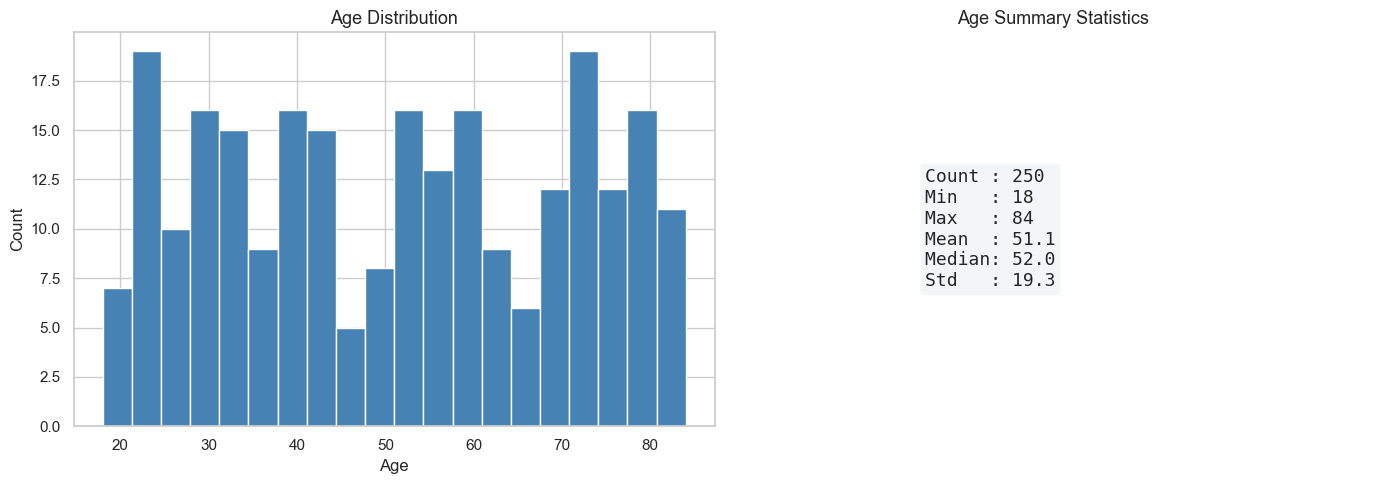

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Summary stats box
stats = df['age'].describe()
axes[1].axis('off')
stats_text = '\n'.join([
    f"Count : {int(stats['count']):,}",
    f"Min   : {int(stats['min'])}",
    f"Max   : {int(stats['max'])}",
    f"Mean  : {stats['mean']:.1f}",
    f"Median: {stats['50%']:.1f}",
    f"Std   : {stats['std']:.1f}",
])
axes[1].text(0.3, 0.5, stats_text, transform=axes[1].transAxes,
             fontsize=13, verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f0f4f8', alpha=0.8))
axes[1].set_title('Age Summary Statistics', fontsize=13)

plt.tight_layout()
plt.show()

## 5. Employment Status Breakdown

Each status is sampled with equal probability, so we expect roughly even distribution across the five categories.

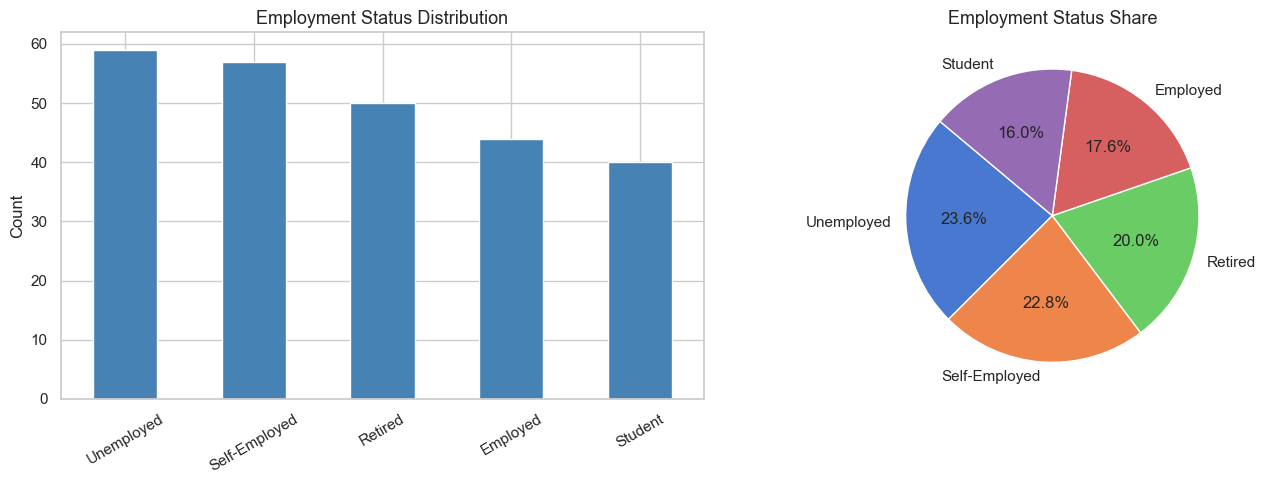

In [6]:
emp_counts = df['employment_status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
emp_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Employment Status Distribution', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
axes[1].pie(
    emp_counts.values,
    labels=emp_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('muted', len(emp_counts)),
)
axes[1].set_title('Employment Status Share', fontsize=13)

plt.tight_layout()
plt.show()

## 6. Income Distribution by Employment Type

Income ranges are tied to employment status, so each group should cluster in its expected range:
- **Employed**: \$30k–\$175k
- **Self-Employed**: \$25k–\$200k  
- **Retired**: \$15k–\$80k
- **Unemployed**: \$0–\$15k
- **Student**: \$0–\$20k

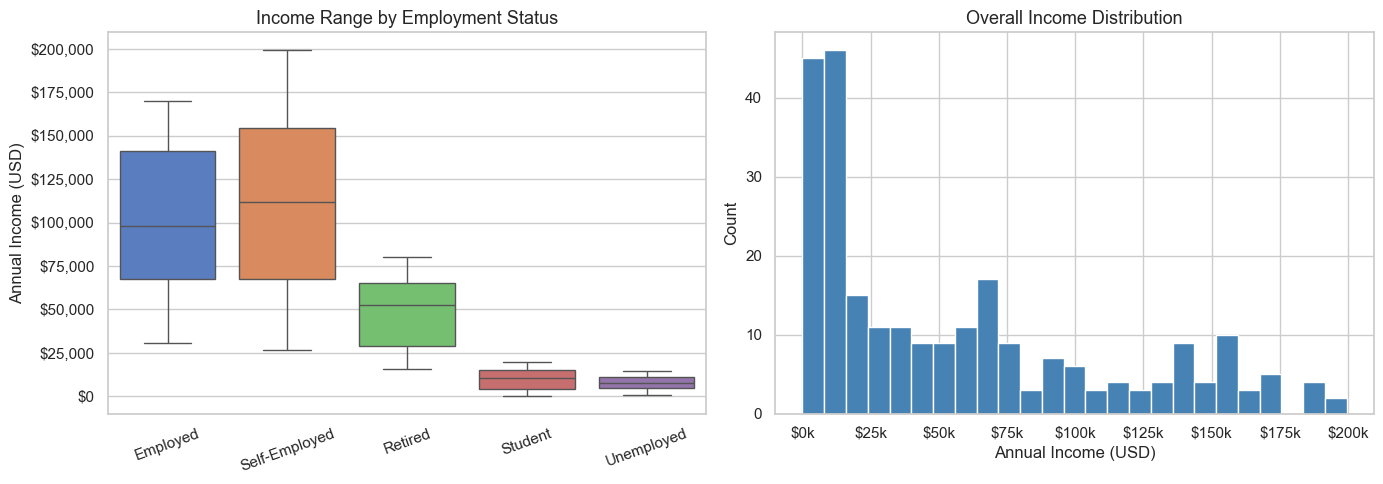

AttributeError: 'DataFrame' object has no attribute 'applymap'

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot — shows range and median per group
order = ['Employed', 'Self-Employed', 'Retired', 'Student', 'Unemployed']
sns.boxplot(
    data=df, x='employment_status', y='annual_income',
    order=order, palette='muted', ax=axes[0]
)
axes[0].set_title('Income Range by Employment Status', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Annual Income (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=20)

# Overall income histogram
axes[1].hist(df['annual_income'], bins=25, color='steelblue', edgecolor='white')
axes[1].set_title('Overall Income Distribution', fontsize=13)
axes[1].set_xlabel('Annual Income (USD)')
axes[1].set_ylabel('Count')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.show()

# Summary table
df.groupby('employment_status')['annual_income'].agg(['min', 'median', 'max', 'mean']) \
  .applymap(lambda x: f'${x:,.0f}') \
  .reindex(order)

## 7. Marital Status Breakdown

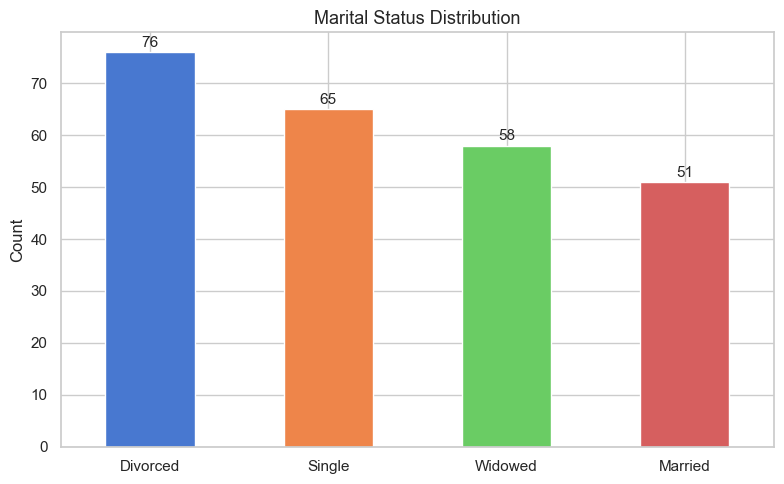

In [8]:
marital_counts = df['marital_status'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
marital_counts.plot(kind='bar', ax=ax, color=sns.color_palette('muted', len(marital_counts)), edgecolor='white')
ax.set_title('Marital Status Distribution', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)

for i, v in enumerate(marital_counts.values):
    ax.text(i, v + 1, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## 8. Geographic Spread — Top States

With the `zipcodes` library providing real city/state/zip associations, every address maps to a real US location. This chart shows which states appear most often in our population.

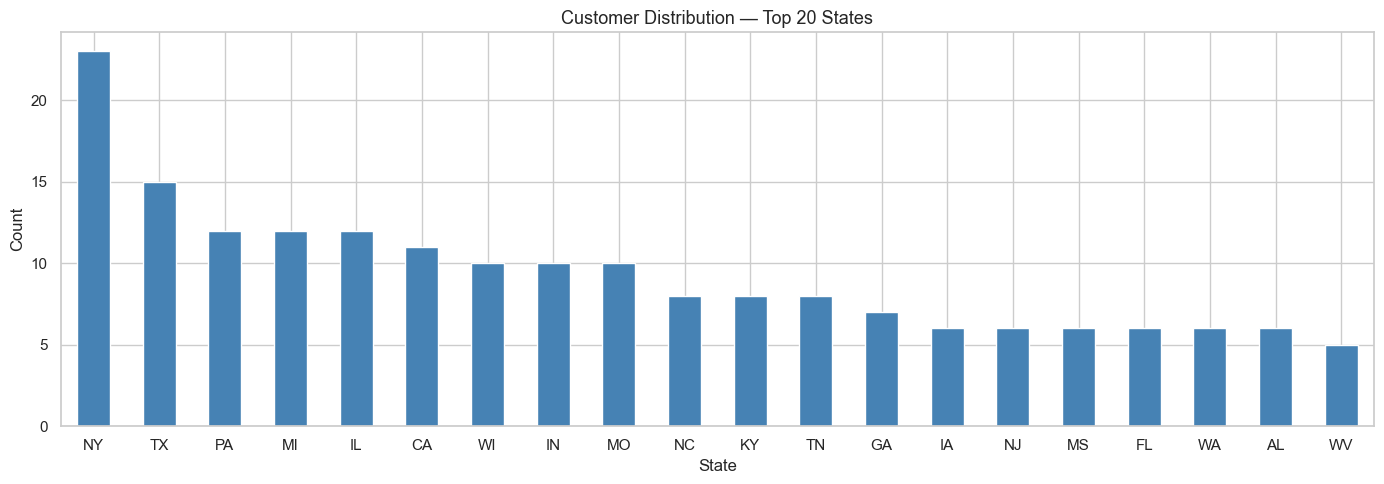

Customers span 45 unique states


In [9]:
state_counts = df['state'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 5))
state_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Customer Distribution — Top 20 States', fontsize=13)
ax.set_xlabel('State')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f'Customers span {df["state"].nunique()} unique states')

## 9. Customer Tenure

How long have customers been with the bank? We sample uniformly between 1 and 20 years, so the distribution should be flat.

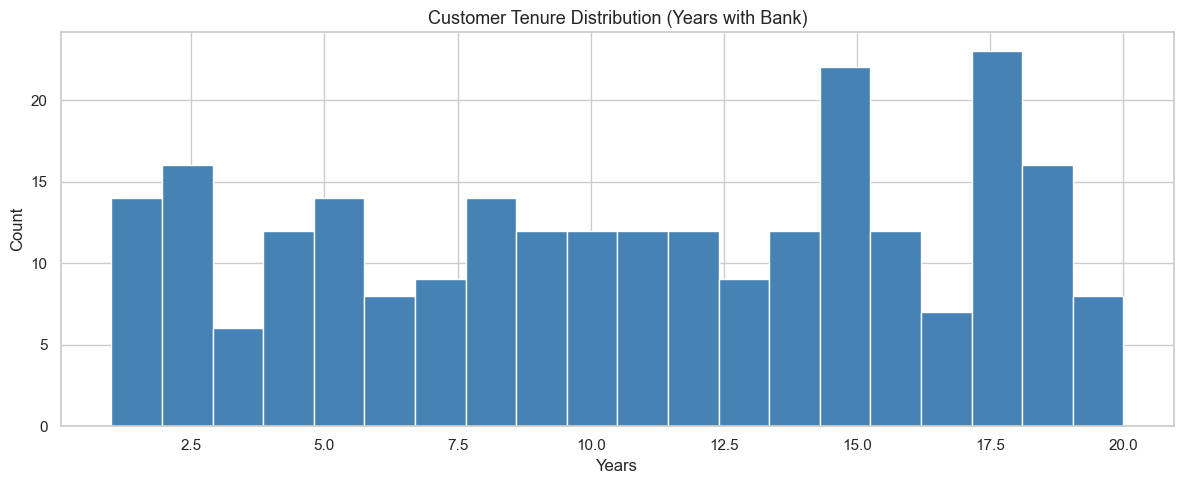

Tenure range : 1–20 years
Mean tenure  : 10.9 years


In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df['tenure_years'], bins=20, color='steelblue', edgecolor='white')
ax.set_title('Customer Tenure Distribution (Years with Bank)', fontsize=13)
ax.set_xlabel('Years')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Tenure range : {df["tenure_years"].min()}–{df["tenure_years"].max()} years')
print(f'Mean tenure  : {df["tenure_years"].mean():.1f} years')

## 10. Export Customer Data

Write the generated customer records to `data/outputs/` in both JSON and CSV format, ready for Snowflake loading.

In [11]:
from src.utils.exporters import write_json, write_csv

output_dir = Path.cwd().parent / 'data' / 'outputs'
output_dir.mkdir(parents=True, exist_ok=True)

write_json(customers, output_dir / 'customers.json')
write_csv(customers, output_dir / 'customers.csv')

print(f'Files written to: {output_dir.resolve()}')

Files written to: /Users/gabrielolson/projects/synthetic-data-creation/data/outputs
